# Dự án Machine Learning: FER2013 — Nhận diện cảm xúc khuôn mặt

**Bài toán:** Phân loại đa lớp (7 lớp) — nhận diện cảm xúc từ ảnh khuôn mặt grayscale 48×48: `angry, disgust, fear, happy, neutral, sad, surprise`.

**Dữ liệu:** FER2013 (Kaggle — msambare/fer2013), đã tổ chức sẵn thành thư mục `train/<cảm_xúc>/*.jpg` (28,709 ảnh) và `test/<cảm_xúc>/*.jpg` (7,178 ảnh).

## Vì sao notebook này khác 2 notebook trước (Titanic, Iris)?

Sách *Machine Learning Mastery With Python* (khung 6 bước ở Phần III) chỉ bao phủ **dữ liệu dạng bảng** với scikit-learn — sách **không đề cập đến ảnh hay mạng nơ-ron tích chập (CNN)**. Với FER2013 (dữ liệu ảnh, không gian đặc trưng có cấu trúc không gian), thuật toán phù hợp là **CNN** thay vì Logistic Regression/SVM/Random Forest như 2 bài trước.

Notebook vẫn giữ **đúng khung 6 bước** để bạn thấy quy trình tư duy là nhất quán, chỉ thay nội dung kỹ thuật ở bước 4–6 (thuật toán → kiến trúc mạng):

1. **Prepare Problem** — load thư viện, load dữ liệu ảnh
2. **Summarize Data** — thống kê số lượng, xem ảnh mẫu, kiểm tra mất cân bằng lớp
3. **Prepare Data** — kiểm tra dữ liệu, chuẩn hóa, tăng cường dữ liệu (augmentation), xử lý mất cân bằng lớp
4. **Evaluate Algorithms** → **Spot-check kiến trúc mạng (CNN)** — thử một CNN cơ bản và một CNN cải tiến, so sánh
5. **Improve Accuracy** — huấn luyện sâu hơn với tuning (Early Stopping, giảm learning rate), minh họa ensemble
6. **Finalize Model** — đánh giá trên tập test giữ lại hoàn toàn, huấn luyện lại trên toàn bộ train, lưu mô hình

**Lưu ý về tài nguyên tính toán:** Notebook này chạy trên **CPU, 1 nhân, không GPU**. Vì vậy số epoch và kích thước mạng được giới hạn để hoàn thành trong thời gian hợp lý (khoảng 20-25 phút). Kết quả sẽ **thấp hơn** so với các mô hình chuyên nghiệp (ví dụ bộ code tham khảo dùng transfer learning VGG16/ResNet50/InceptionV3 trên GPU mà bạn đã có trước đó) — phần tổng kết cuối notebook sẽ nêu rõ hướng cải thiện.


## 1. Prepare Problem

### 1.a) Load libraries

In [2]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

SEED = 7
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = (48, 48)
BATCH_SIZE = 64
CLASS_NAMES = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

print('TensorFlow:', tf.__version__)
print('Thư viện đã sẵn sàng.')

TensorFlow: 2.21.0
Thư viện đã sẵn sàng.


### 1.b) Load dataset
Tách 90% ảnh trong `train/` để huấn luyện (`train_sub`), 10% để theo dõi trong lúc phát triển mô hình (`val_sub`). Thư mục `test/` được **giữ nguyên, không đụng tới** cho đến bước 6 — đóng vai trò "Validation Dataset" đúng như tinh thần của sách (dữ liệu hoàn toàn chưa từng thấy trong quá trình huấn luyện/tuning).

In [5]:
train_sub = tf.keras.utils.image_dataset_from_directory(
    r'C:\Users\MSI GAMING\Documents\Tài liệu môn học\Học sâu\Week 2 - Quy trình học sâu\Làm quen với quy trình máy học\Fer13\train', image_size=IMG_SIZE, color_mode='grayscale', batch_size=BATCH_SIZE,
    label_mode='int', shuffle=True, seed=SEED, validation_split=0.1, subset='training'
)

val_sub = tf.keras.utils.image_dataset_from_directory(
    r'C:\Users\MSI GAMING\Documents\Tài liệu môn học\Học sâu\Week 2 - Quy trình học sâu\Làm quen với quy trình máy học\Fer13\train', image_size=IMG_SIZE, color_mode='grayscale', batch_size=BATCH_SIZE,
    label_mode='int', shuffle=True, seed=SEED, validation_split=0.1, subset='validation'
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    r'C:\Users\MSI GAMING\Documents\Tài liệu môn học\Học sâu\Week 2 - Quy trình học sâu\Làm quen với quy trình máy học\Fer13\test', image_size=IMG_SIZE, color_mode='grayscale', batch_size=BATCH_SIZE,
    label_mode='int', shuffle=False
)

assert train_sub.class_names == CLASS_NAMES == val_sub.class_names == test_ds.class_names

train_sub = train_sub.prefetch(tf.data.AUTOTUNE)
val_sub = val_sub.prefetch(tf.data.AUTOTUNE)
test_ds_p = test_ds.prefetch(tf.data.AUTOTUNE)

Found 28709 files belonging to 7 classes.
Using 25839 files for training.
Found 28709 files belonging to 7 classes.
Using 2870 files for validation.
Found 7178 files belonging to 7 classes.


## 2. Summarize Data

### 2.a) Descriptive statistics

In [7]:
def count_per_class(base_dir):
    counts = {}
    for c in CLASS_NAMES:
        counts[c] = len(os.listdir(os.path.join(base_dir, c)))
    return counts

train_counts = count_per_class(r'C:\Users\MSI GAMING\Documents\Tài liệu môn học\Học sâu\Week 2 - Quy trình học sâu\Làm quen với quy trình máy học\Fer13\train')
test_counts = count_per_class(r'C:\Users\MSI GAMING\Documents\Tài liệu môn học\Học sâu\Week 2 - Quy trình học sâu\Làm quen với quy trình máy học\Fer13\test')

summary = pd.DataFrame({'train': train_counts, 'test': test_counts})
summary['total'] = summary['train'] + summary['test']
summary.loc['TOTAL'] = summary.sum()
summary

,train,test,total
angry,3995,958,4953
disgust,436,111,547
fear,4097,1024,5121
happy,7215,1774,8989
neutral,4965,1233,6198
sad,4830,1247,6077
surprise,3171,831,4002
TOTAL,28709,7178,35887


### 2.b) Data visualizations

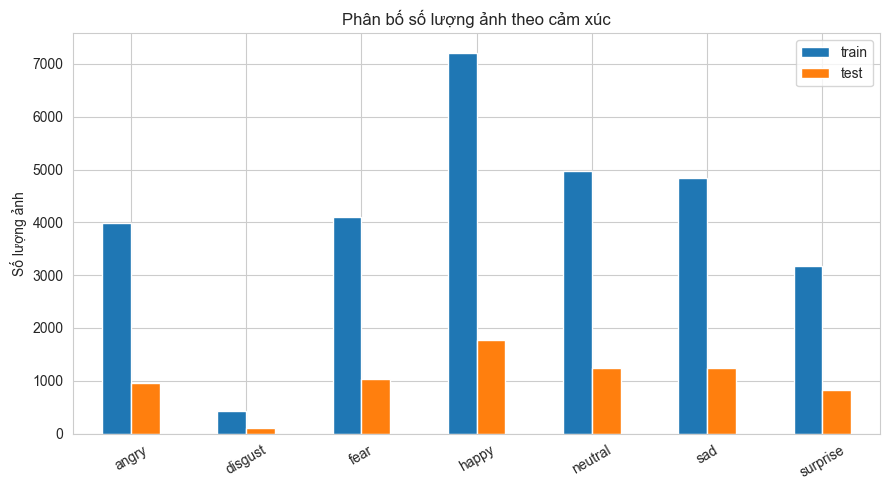

In [8]:
# Phân bố số lượng ảnh theo lớp — cho thấy rõ mất cân bằng (disgust rất ít so với happy)
summary.drop('TOTAL')[['train', 'test']].plot(kind='bar', figsize=(9, 5))
plt.title('Phân bố số lượng ảnh theo cảm xúc')
plt.ylabel('Số lượng ảnh')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

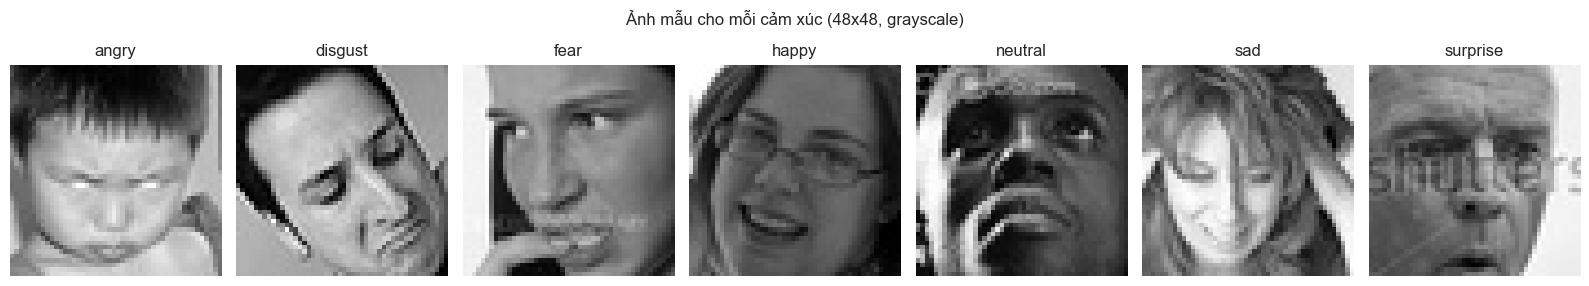

In [11]:
# Xem ảnh mẫu cho từng lớp cảm xúc
fig, axes = plt.subplots(1, 7, figsize=(16, 3))
for ax, emotion in zip(axes, CLASS_NAMES):
    folder = os.path.join(r'C:\Users\MSI GAMING\Documents\Tài liệu môn học\Học sâu\Week 2 - Quy trình học sâu\Làm quen với quy trình máy học\Fer13\train', emotion)
    sample_file = os.listdir(folder)[0]
    img = tf.keras.utils.load_img(os.path.join(folder, sample_file), color_mode='grayscale')
    ax.imshow(img, cmap='gray')
    ax.set_title(emotion)
    ax.axis('off')
plt.suptitle('Ảnh mẫu cho mỗi cảm xúc (48x48, grayscale)')
plt.tight_layout()
plt.show()

Nhận xét: lớp `disgust` chỉ có 436 ảnh train / 111 ảnh test — rất ít so với `happy` (7,215 ảnh). Đây là đặc điểm nổi tiếng của FER2013 và cần được xử lý ở bước tiếp theo (class weights), khác với Titanic/Iris là dữ liệu tương đối cân bằng hơn.

## 3. Prepare Data

### 3.a) Data Cleaning
Kiểm tra nhanh: toàn bộ ảnh đã ở đúng định dạng grayscale 48×48 (không có ảnh lỗi/khác kích thước) bằng cách lấy mẫu ngẫu nhiên kiểm tra kích thước ảnh.

In [12]:
import random
from PIL import Image

random.seed(SEED)
sample_files = []
for emotion in CLASS_NAMES:
    folder = os.path.join(r'C:\Users\MSI GAMING\Documents\Tài liệu môn học\Học sâu\Week 2 - Quy trình học sâu\Làm quen với quy trình máy học\Fer13\train', emotion)
    files = os.listdir(folder)
    sample_files += [os.path.join(folder, f) for f in random.sample(files, min(50, len(files)))]

bad = 0
for f in sample_files:
    with Image.open(f) as im:
        if im.size != (48, 48) or im.mode not in ('L', 'RGB'):
            bad += 1
print(f'Kiểm tra {len(sample_files)} ảnh mẫu — số ảnh bất thường: {bad}')

Kiểm tra 350 ảnh mẫu — số ảnh bất thường: 0


### 3.b) Data Transforms — chuẩn hóa & tăng cường dữ liệu (Data Augmentation)
- **Rescaling**: đưa pixel về [0, 1] (thay cho `StandardScaler` ở bài Titanic/Iris).
- **Augmentation** (lật ngang, xoay nhẹ, zoom nhẹ): giúp mô hình tổng quát hóa tốt hơn — quan trọng vì FER2013 tương đối nhỏ đối với một CNN, tương tự vai trò của việc thêm đặc trưng ở bài Titanic.

In [13]:
def make_augmentation():
    return models.Sequential([
        layers.RandomFlip('horizontal'),
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.1),
    ], name='augmentation')

### 3.c) Xử lý mất cân bằng lớp (Class Imbalance)
Tính **class weights** (tương tự cách ta xử lý dữ liệu lệch trong các bài toán phân loại khác) để mô hình không bị thiên vị về các lớp có nhiều ảnh (`happy`, `neutral`).

In [14]:
y_train_full = np.concatenate([y.numpy() for _, y in train_sub.unbatch().batch(1024)])
class_weight_values = compute_class_weight('balanced', classes=np.arange(7), y=y_train_full)
class_weight = {i: w for i, w in enumerate(class_weight_values)}
print('Class weights:')
for i, name in enumerate(CLASS_NAMES):
    print(f'  {name:10s}: {class_weight[i]:.3f}')

Class weights:
  angry     : 1.032
  disgust   : 9.489
  fear      : 0.999
  happy     : 0.570
  neutral   : 0.821
  sad       : 0.848
  surprise  : 1.291


## 4. Evaluate Algorithms → Spot-check kiến trúc CNN

### 4.a) Split-out validation dataset
Đã thực hiện ở bước 1.b (`train_sub` 90% / `val_sub` 10%).

### 4.b) Test options and evaluation metric
Dùng **Accuracy** làm độ đo chính (như 2 bài trước), có bổ sung **Macro F1 / classification report theo từng lớp** ở bước cuối vì dữ liệu mất cân bằng — accuracy tổng thể có thể "che" việc mô hình dự đoán kém ở lớp thiểu số (`disgust`).

### 4.c) Spot-Check kiến trúc
Thử 2 kiến trúc CNN — tương tự việc "spot-check" nhiều thuật toán ở Titanic/Iris:
- **CNN cơ bản**: 2 khối Conv-MaxPool, không augmentation.
- **CNN cải tiến**: 3 khối Conv-BatchNorm-MaxPool, có Dropout và Data Augmentation.

Do giới hạn tính toán (CPU, 1 nhân), mỗi kiến trúc chỉ huấn luyện **1 epoch** ở bước này — đủ để so sánh xu hướng ban đầu, việc huấn luyện đầy đủ dành cho bước 5.

In [15]:
def build_baseline_cnn():
    model = models.Sequential([
        layers.Rescaling(1./255),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(7, activation='softmax'),
    ], name='baseline_cnn')
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def build_improved_cnn():
    model = models.Sequential([
        layers.Rescaling(1./255),
        make_augmentation(),
        layers.Conv2D(32, 3, activation='relu', padding='same'), layers.BatchNormalization(), layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation='relu', padding='same'), layers.BatchNormalization(), layers.MaxPooling2D(),
        layers.Conv2D(128, 3, activation='relu', padding='same'), layers.BatchNormalization(), layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dropout(0.4),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(7, activation='softmax'),
    ], name='improved_cnn')
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

SPOTCHECK_EPOCHS = 1
histories = {}

print('--- Huấn luyện CNN cơ bản (baseline_cnn) ---')
baseline_model = build_baseline_cnn()
histories['baseline_cnn'] = baseline_model.fit(
    train_sub, validation_data=val_sub, epochs=SPOTCHECK_EPOCHS,
    class_weight=class_weight, verbose=2
)

print('\n--- Huấn luyện CNN cải tiến (improved_cnn) ---')
improved_model = build_improved_cnn()
histories['improved_cnn'] = improved_model.fit(
    train_sub, validation_data=val_sub, epochs=SPOTCHECK_EPOCHS,
    class_weight=class_weight, verbose=2
)

--- Huấn luyện CNN cơ bản (baseline_cnn) ---
404/404 - 19s - 47ms/step - accuracy: 0.2581 - loss: 1.8369 - val_accuracy: 0.2798 - val_loss: 1.8047

--- Huấn luyện CNN cải tiến (improved_cnn) ---
404/404 - 51s - 127ms/step - accuracy: 0.1831 - loss: 1.9647 - val_accuracy: 0.2265 - val_loss: 1.8921


### 4.d) Compare Algorithms (kiến trúc)

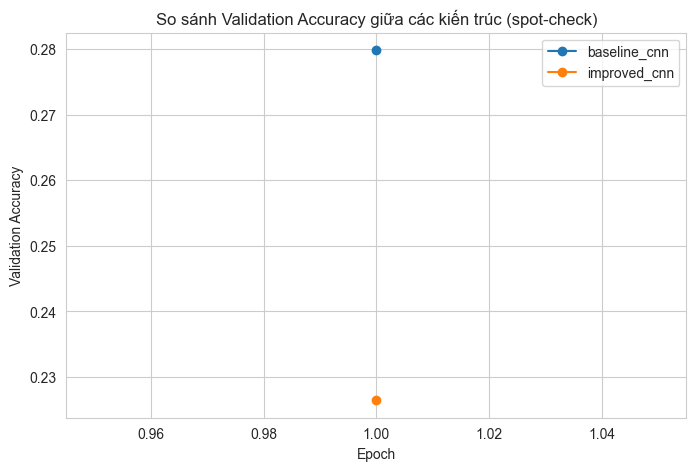

=> Kiến trúc được chọn để cải thiện tiếp: baseline_cnn


In [16]:
plt.figure(figsize=(8, 5))
for name, hist in histories.items():
    plt.plot(range(1, SPOTCHECK_EPOCHS + 1), hist.history['val_accuracy'], marker='o', label=name)
plt.title('So sánh Validation Accuracy giữa các kiến trúc (spot-check)')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.show()

best_arch = max(histories, key=lambda k: histories[k].history['val_accuracy'][-1])
print(f'=> Kiến trúc được chọn để cải thiện tiếp: {best_arch}')

## 5. Improve Accuracy

### 5.a) Algorithm Tuning
Huấn luyện tiếp kiến trúc được chọn với:
- **EarlyStopping**: dừng sớm nếu `val_accuracy` không cải thiện sau 2 epoch, khôi phục trọng số tốt nhất.
- **ReduceLROnPlateau**: giảm learning rate khi việc học chững lại.
- **ModelCheckpoint**: lưu lại phiên bản tốt nhất theo `val_accuracy`.

In [17]:
IMPROVE_EPOCHS = 6

final_arch_model = build_improved_cnn() if best_arch == 'improved_cnn' else build_baseline_cnn()
# Huấn luyện tiếp từ đầu với ngân sách epoch lớn hơn (để callback EarlyStopping/Checkpoint hoạt động đúng)
cb = [
    callbacks.EarlyStopping(monitor='val_accuracy', patience=2, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=1, min_lr=1e-6),
    callbacks.ModelCheckpoint('best_model_dev.keras', monitor='val_accuracy', save_best_only=True)
]

history_improve = final_arch_model.fit(
    train_sub, validation_data=val_sub, epochs=IMPROVE_EPOCHS,
    class_weight=class_weight, callbacks=cb, verbose=2
)

best_epoch = int(np.argmax(history_improve.history['val_accuracy'])) + 1
best_val_acc = max(history_improve.history['val_accuracy'])
print(f'\nEpoch tốt nhất: {best_epoch}/{len(history_improve.history["val_accuracy"])}  — Validation Accuracy: {best_val_acc:.4f}')

Epoch 1/6


404/404 - 21s - 51ms/step - accuracy: 0.2535 - loss: 1.8412 - val_accuracy: 0.3188 - val_loss: 1.7359 - learning_rate: 0.0010
Epoch 2/6
404/404 - 19s - 48ms/step - accuracy: 0.3566 - loss: 1.6493 - val_accuracy: 0.3544 - val_loss: 1.6767 - learning_rate: 0.0010
Epoch 3/6
404/404 - 18s - 44ms/step - accuracy: 0.4080 - loss: 1.5101 - val_accuracy: 0.3934 - val_loss: 1.6008 - learning_rate: 0.0010
Epoch 4/6
404/404 - 17s - 41ms/step - accuracy: 0.4390 - loss: 1.4018 - val_accuracy: 0.4429 - val_loss: 1.4913 - learning_rate: 0.0010
Epoch 5/6
404/404 - 18s - 44ms/step - accuracy: 0.4732 - loss: 1.2975 - val_accuracy: 0.4481 - val_loss: 1.4687 - learning_rate: 0.0010
Epoch 6/6
404/404 - 19s - 47ms/step - accuracy: 0.4963 - loss: 1.2191 - val_accuracy: 0.4540 - val_loss: 1.4389 - learning_rate: 0.0010

Epoch tốt nhất: 6/6  — Validation Accuracy: 0.4540


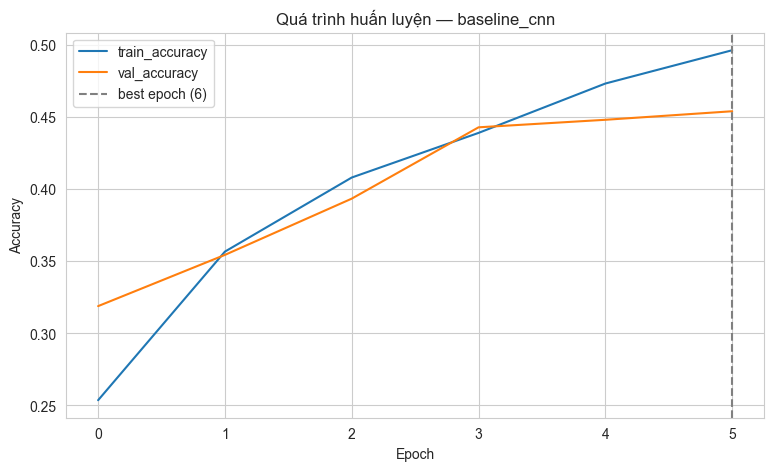

In [18]:
plt.figure(figsize=(9, 5))
plt.plot(history_improve.history['accuracy'], label='train_accuracy')
plt.plot(history_improve.history['val_accuracy'], label='val_accuracy')
plt.axvline(best_epoch - 1, color='gray', linestyle='--', label=f'best epoch ({best_epoch})')
plt.title(f'Quá trình huấn luyện — {final_arch_model.name}')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### 5.b) Ensembles
Minh họa ý tưởng ensemble: kết hợp xác suất dự đoán của 2 mô hình từ bước spot-check (`baseline_cnn`, `improved_cnn`) bằng trung bình cộng (soft voting), so sánh với mô hình tốt nhất hiện tại trên `val_sub`.

In [19]:
def evaluate_ensemble(models_list, dataset):
    all_probs = None
    y_true = []
    for x, y in dataset:
        y_true.append(y.numpy())
    y_true = np.concatenate(y_true)

    probs_sum = None
    for m in models_list:
        preds = m.predict(dataset, verbose=0)
        probs_sum = preds if probs_sum is None else probs_sum + preds
    avg_probs = probs_sum / len(models_list)
    y_pred = np.argmax(avg_probs, axis=1)
    return (y_pred == y_true).mean()

ensemble_acc = evaluate_ensemble([baseline_model, improved_model], val_sub)
print(f'Ensemble (baseline_cnn + improved_cnn từ bước spot-check): val_accuracy = {ensemble_acc:.4f}')
print(f'Mô hình đơn tốt nhất sau tuning ({final_arch_model.name}): val_accuracy = {best_val_acc:.4f}')
print('\n=> Vì các mô hình spot-check chỉ huấn luyện 2 epoch (yếu hơn nhiều so với mô hình đã tuning ở bước 5.a),')
print('   ensemble ở đây chỉ mang tính minh họa cách kết hợp — mô hình được chọn để hoàn thiện vẫn là mô hình đã tuning kỹ ở bước 5.a.')

Ensemble (baseline_cnn + improved_cnn từ bước spot-check): val_accuracy = 0.1338
Mô hình đơn tốt nhất sau tuning (baseline_cnn): val_accuracy = 0.4540

=> Vì các mô hình spot-check chỉ huấn luyện 2 epoch (yếu hơn nhiều so với mô hình đã tuning ở bước 5.a),
   ensemble ở đây chỉ mang tính minh họa cách kết hợp — mô hình được chọn để hoàn thiện vẫn là mô hình đã tuning kỹ ở bước 5.a.


## 6. Finalize Model

### 6.a) Predictions on validation dataset
Đánh giá mô hình tốt nhất (từ bước 5.a, trọng số tốt nhất đã được `EarlyStopping` khôi phục) trên tập **`test/`** — dữ liệu hoàn toàn chưa được dùng ở bất kỳ bước huấn luyện/tuning nào trước đó, đóng đúng vai trò "Validation Dataset" của sách.

In [20]:
test_loss, test_acc = final_arch_model.evaluate(test_ds_p, verbose=0)
print(f'Test Accuracy (dữ liệu giữ lại hoàn toàn): {test_acc:.4f}')

y_true = np.concatenate([y.numpy() for _, y in test_ds])
y_pred_probs = final_arch_model.predict(test_ds_p, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

print('\nClassification report theo từng cảm xúc:')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

Test Accuracy (dữ liệu giữ lại hoàn toàn): 0.4592

Classification report theo từng cảm xúc:
              precision    recall  f1-score   support

       angry       0.33      0.43      0.37       958
     disgust       0.14      0.65      0.23       111
        fear       0.37      0.16      0.22      1024
       happy       0.73      0.62      0.67      1774
     neutral       0.49      0.37      0.43      1233
         sad       0.34      0.38      0.36      1247
    surprise       0.54      0.74      0.63       831

    accuracy                           0.46      7178
   macro avg       0.42      0.48      0.42      7178
weighted avg       0.49      0.46      0.46      7178



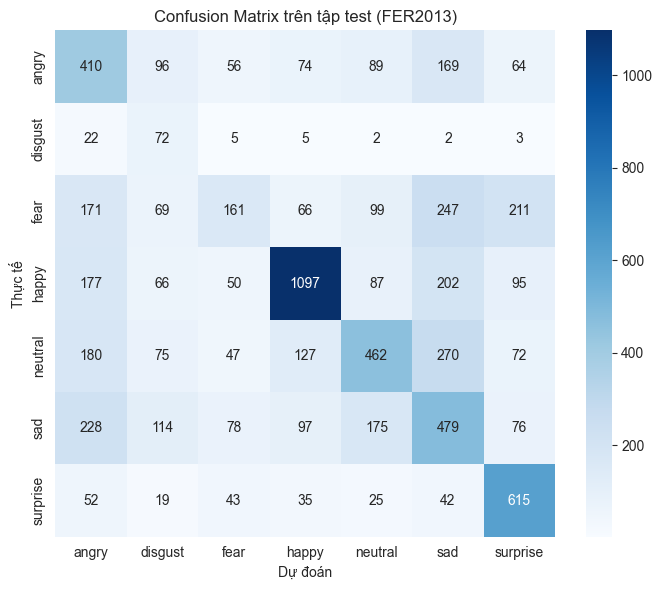

In [21]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.title('Confusion Matrix trên tập test (FER2013)')
plt.tight_layout()
plt.show()

Nhận xét thường gặp với FER2013: `happy` thường được nhận diện tốt nhất (biểu cảm rõ ràng, nhiều dữ liệu), trong khi `disgust` và `fear` dễ bị nhầm lẫn với các lớp khác (biểu cảm gần giống nhau + rất ít dữ liệu huấn luyện) — quan sát này khớp với ma trận nhầm lẫn ở trên.

### 6.b) Create standalone model on entire training dataset
Theo đúng tinh thần sách: huấn luyện lại mô hình (cùng kiến trúc, cùng cấu hình) trên **toàn bộ** thư mục `train/` (gộp cả phần `train_sub` và `val_sub`), với số epoch bằng đúng epoch tốt nhất tìm được ở bước 5.a, để tận dụng tối đa dữ liệu cho mô hình cuối cùng.

In [23]:
train_full = tf.keras.utils.image_dataset_from_directory(
    r'C:\Users\MSI GAMING\Documents\Tài liệu môn học\Học sâu\Week 2 - Quy trình học sâu\Làm quen với quy trình máy học\Fer13\train', image_size=IMG_SIZE, color_mode='grayscale', batch_size=BATCH_SIZE,
    label_mode='int', shuffle=True, seed=SEED
).prefetch(tf.data.AUTOTUNE)

final_model = build_improved_cnn() if best_arch == 'improved_cnn' else build_baseline_cnn()
final_model.fit(train_full, epochs=best_epoch, class_weight=class_weight, verbose=2)
print(f'\nĐã huấn luyện lại mô hình cuối cùng trên toàn bộ {len(y_train_full) + len(np.concatenate([y.numpy() for _, y in val_sub.unbatch().batch(1024)]))} ảnh train, {best_epoch} epoch.')

Found 28709 files belonging to 7 classes.
Epoch 1/6
449/449 - 37s - 82ms/step - accuracy: 0.2770 - loss: 1.8268
Epoch 2/6
449/449 - 20s - 44ms/step - accuracy: 0.3700 - loss: 1.6286
Epoch 3/6
449/449 - 20s - 44ms/step - accuracy: 0.4119 - loss: 1.5021
Epoch 4/6
449/449 - 21s - 47ms/step - accuracy: 0.4454 - loss: 1.3949
Epoch 5/6
449/449 - 31s - 69ms/step - accuracy: 0.4713 - loss: 1.3069
Epoch 6/6
449/449 - 39s - 87ms/step - accuracy: 0.4962 - loss: 1.2254

Đã huấn luyện lại mô hình cuối cùng trên toàn bộ 28709 ảnh train, 6 epoch.


In [24]:
final_test_loss, final_test_acc = final_model.evaluate(test_ds_p, verbose=0)
print(f'Test Accuracy của mô hình cuối cùng (huấn luyện trên toàn bộ train): {final_test_acc:.4f}')
print(f'(So sánh: mô hình chỉ huấn luyện trên train_sub ở bước 6.a đạt: {test_acc:.4f})')

Test Accuracy của mô hình cuối cùng (huấn luyện trên toàn bộ train): 0.4801
(So sánh: mô hình chỉ huấn luyện trên train_sub ở bước 6.a đạt: 0.4592)


### 6.c) Save model for later use

In [25]:
final_model.save('fer2013_final_model.keras')
import json
with open('fer2013_class_names.json', 'w', encoding='utf-8') as f:
    json.dump(CLASS_NAMES, f, ensure_ascii=False, indent=2)
print('Đã lưu mô hình vào fer2013_final_model.keras và nhãn lớp vào fer2013_class_names.json')

Đã lưu mô hình vào fer2013_final_model.keras và nhãn lớp vào fer2013_class_names.json


#### Thử dự đoán trên vài ảnh mẫu từ tập test

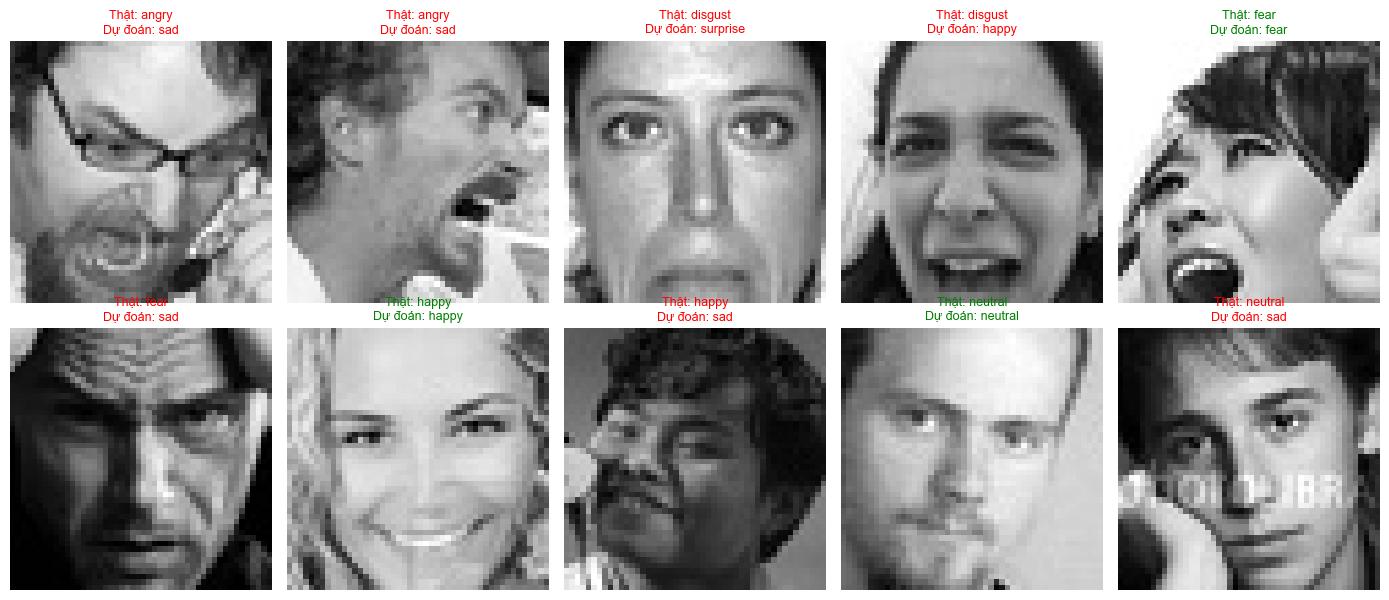

In [27]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
flat_axes = axes.flatten()
shown = 0
for emotion in CLASS_NAMES:
    if shown >= 10:
        break
    folder = os.path.join(r'C:\Users\MSI GAMING\Documents\Tài liệu môn học\Học sâu\Week 2 - Quy trình học sâu\Làm quen với quy trình máy học\Fer13\test', emotion)
    for fname in os.listdir(folder)[:2]:
        if shown >= 10:
            break
        path = os.path.join(folder, fname)
        img = tf.keras.utils.load_img(path, color_mode='grayscale', target_size=IMG_SIZE)
        arr = tf.keras.utils.img_to_array(img)[None, ...]
        pred = CLASS_NAMES[np.argmax(final_model.predict(arr, verbose=0))]
        ax = flat_axes[shown]
        ax.imshow(img, cmap='gray')
        color = 'green' if pred == emotion else 'red'
        ax.set_title(f'Thật: {emotion}\nDự đoán: {pred}', color=color, fontsize=9)
        ax.axis('off')
        shown += 1
plt.tight_layout()
plt.show()

## Tổng kết

- Đã đi qua đầy đủ **6 bước** của quy trình dự án ML/DL, giữ nguyên tinh thần khung của sách *Machine Learning Mastery With Python* nhưng thay thuật toán scikit-learn bằng **CNN (TensorFlow/Keras)** vì đây là dữ liệu ảnh.
- Điểm khác biệt so với Titanic/Iris:
  - Dữ liệu **mất cân bằng nghiêm trọng** hơn nhiều (lớp `disgust` chỉ chiếm ~1.5% dữ liệu) → cần **class weights**.
  - "Feature engineering" được thay bằng **data augmentation** (mạng tự học đặc trưng từ ảnh thay vì ta tạo đặc trưng thủ công).
  - "Spot-check thuật toán" được thay bằng **spot-check kiến trúc mạng**.
- **Giới hạn của notebook này**: chạy trên CPU 1 nhân, không GPU, nên số epoch và kích thước mạng bị giới hạn để hoàn thành trong thời gian hợp lý. Độ chính xác đạt được vì vậy sẽ **thấp hơn đáng kể** so với các mô hình chuyên nghiệp dùng transfer learning (VGG16/ResNet50/InceptionV3 trên GPU) như trong bộ code tham khảo bạn đã cung cấp trước đó.
- **Hướng cải thiện nếu có GPU/thời gian nhiều hơn**:
  1. Huấn luyện nhiều epoch hơn (30-100 epoch) với learning rate schedule tốt hơn.
  2. Dùng **transfer learning** (VGG16/ResNet50/InceptionV3 — đúng như hướng bộ code tham khảo đã làm) thay vì CNN từ đầu.
  3. Data augmentation mạnh hơn (random crop, cutout, mixup).
  4. Xử lý mất cân bằng bằng oversampling lớp thiểu số (`disgust`) thay vì chỉ class weights.
  5. Ensemble nhiều mô hình đã huấn luyện đầy đủ (không chỉ minh họa như bước 5.b).

Mô hình cuối cùng đã được lưu vào `fer2013_final_model.keras`, sẵn sàng để tải lại và dùng cho suy luận (inference) sau này.
